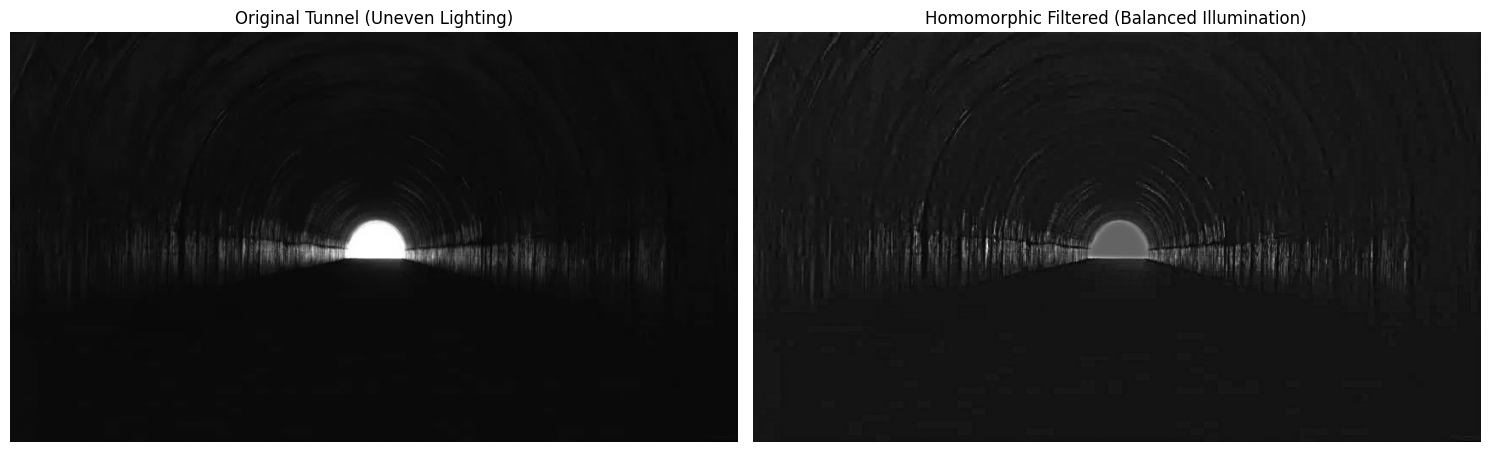

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
im = cv2.imread('images/a1images/tunnel.webp', cv2.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

# 1. Log Transformation 
# We add 1 to avoid log(0) and use float32 for precision
im_log = np.log1p(im.astype(np.float32))

# 2. Shift to Frequency Domain
dft = np.fft.fft2(im_log)
dft_shift = np.fft.fftshift(dft)

# 3. Create a Butterwort-style Homomorphic Filter
rows, cols = im.shape
crow, ccol = rows//2, cols//2
y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
dist_sq = x*x + y*y

# Parameters
D0 = 30        # Cutoff frequency
gH = 1.5       # High-frequency gain (boosts details/reflectance)
gL = 0.5       # Low-frequency gain (suppresses uneven illumination)
c = 1          # Sharpness of the slope

# Gaussian High-pass filter formula adjusted for Homomorphic
h = (gH - gL) * (1 - np.exp(-c * (dist_sq / (2 * (D0**2))))) + gL

# 4. Apply Filter and Inverse Transform
filtered_dft = dft_shift * h
im_back = np.fft.ifftshift(filtered_dft)
im_back = np.fft.ifft2(im_back)

# 5. Exponential Transformation (Inverse Log)
im_exp = np.expm1(np.real(im_back))

# 6. Normalize to 0-255 for display
result = cv2.normalize(im_exp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Tunnel (Uneven Lighting)')
ax[0].axis('off')

ax[1].imshow(result, cmap='gray')
ax[1].set_title('Homomorphic Filtered (Balanced Illumination)')
ax[1].axis('off')

plt.tight_layout()
plt.show()